In [1]:
import pandas as pd

# Cargar dataset preparado
ruta_datos = "../data/suaci_2025_preparado.csv.gz"
df = pd.read_csv(ruta_datos, compression="gzip", low_memory=False)
print(f"Datos cargados: {df.shape[0]:,} filas, {df.shape[1]} columnas")

Datos cargados: 1,458,570 filas, 11 columnas


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Separar variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=['target'])
y = df['target']

# 2. División Train / Test estratificada (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Set de Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Set de Prueba:        {X_test.shape[0]:,} filas")

# 3. Definir columnas por tipo
cols_categoricas = ['categoria', 'tipo', 'canal', 'comuna', 'dia_semana']
cols_numericas = ['mes', 'hora', 'es_fin_de_semana']

# 4. Pipeline de Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_categoricas),
        ('num', 'passthrough', cols_numericas)
    ]
)

# 5. Muestra representativa de 150k filas para entrenar de forma ágil
muestra_idx = X_train.sample(n=150000, random_state=42).index
X_train_sub = X_train.loc[muestra_idx]
y_train_sub = y_train.loc[muestra_idx]

# 6. Transformar los sets
print("\nTransformando variables...")
X_train_prep = preprocessor.fit_transform(X_train_sub)
X_test_prep = preprocessor.transform(X_test)

print(f"Total de variables generadas tras encoding: {X_train_prep.shape[1]}")

Set de Entrenamiento: 1,166,856 filas
Set de Prueba:        291,714 filas

Transformando variables...
Total de variables generadas tras encoding: 85


Entrenando Regresión Logística...

--- REPORTE REGRESIÓN LOGÍSTICA ---
                 precision    recall  f1-score   support

No Resuelto (0)       0.59      0.89      0.71     37631
    Cerrado (1)       0.98      0.91      0.94    254083

       accuracy                           0.91    291714
      macro avg       0.79      0.90      0.83    291714
   weighted avg       0.93      0.91      0.91    291714

ROC-AUC Score: 0.9650

Entrenando Random Forest (100 árboles)...

--- REPORTE RANDOM FOREST ---
                 precision    recall  f1-score   support

No Resuelto (0)       0.58      0.93      0.72     37631
    Cerrado (1)       0.99      0.90      0.94    254083

       accuracy                           0.91    291714
      macro avg       0.79      0.92      0.83    291714
   weighted avg       0.94      0.91      0.91    291714

ROC-AUC Score: 0.9745


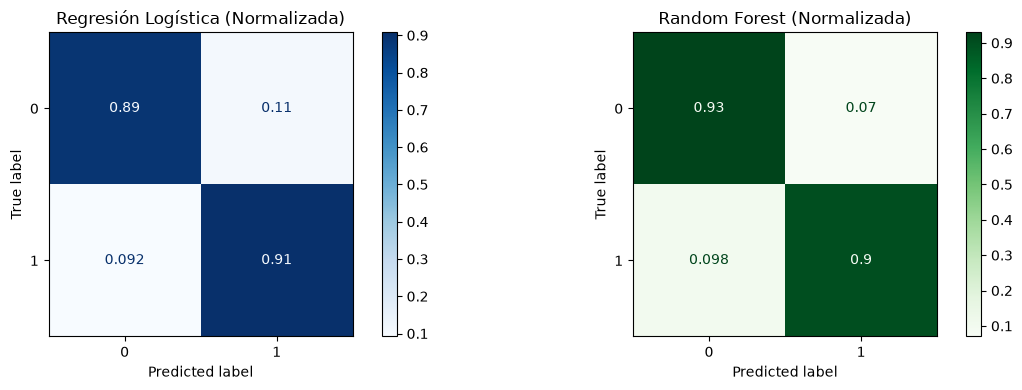

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Modelo 1: Regresión Logística (Baseline)
print("Entrenando Regresión Logística...")
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_prep, y_train_sub)

y_pred_lr = lr_model.predict(X_test_prep)
y_proba_lr = lr_model.predict_proba(X_test_prep)[:, 1]

print("\n--- REPORTE REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_lr, target_names=['No Resuelto (0)', 'Cerrado (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

# 2. Modelo 2: Random Forest Classifier
print("\nEntrenando Random Forest (100 árboles)...")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15, 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42
)
rf_model.fit(X_train_prep, y_train_sub)

y_pred_rf = rf_model.predict(X_test_prep)
y_proba_rf = rf_model.predict_proba(X_test_prep)[:, 1]

print("\n--- REPORTE RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf, target_names=['No Resuelto (0)', 'Cerrado (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

# 3. Visualización comparativa de Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap='Blues', normalize='true')
axes[0].set_title("Regresión Logística (Normalizada)")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens', normalize='true')
axes[1].set_title("Random Forest (Normalizada)")

plt.tight_layout()
plt.show()

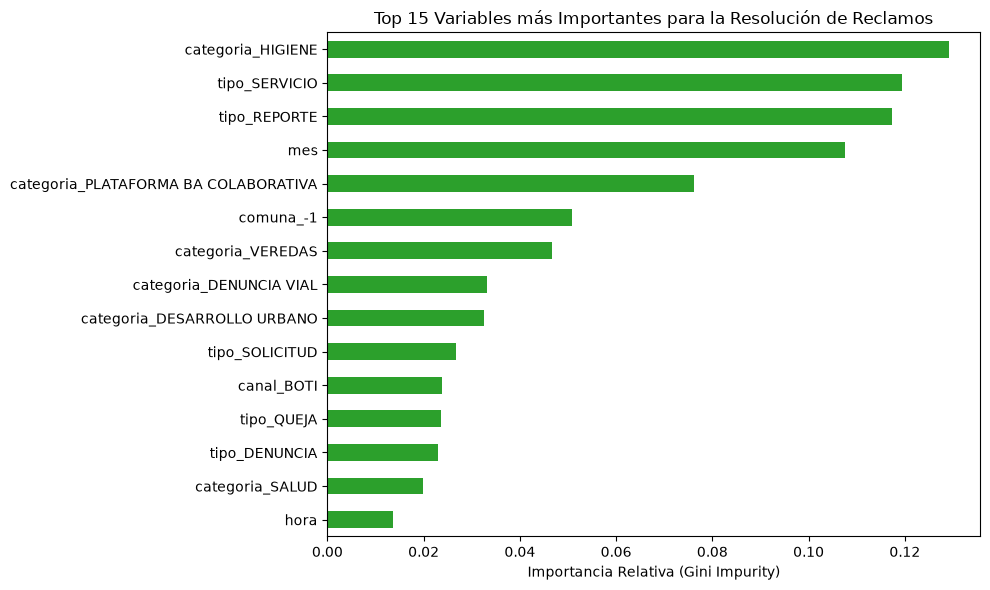

✅ Modelo ('modelo_random_forest_suaci.pkl') y preprocesador ('preprocesador_suaci.pkl') exportados con éxito.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# 1. Recuperar nombres de todas las columnas codificadas
nombres_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(cols_categoricas)
nombres_todas = list(nombres_cat) + cols_numericas

# 2. Calcular la importancia de variables del Random Forest
importancias = pd.Series(rf_model.feature_importances_, index=nombres_todas)
top_15 = importancias.sort_values(ascending=False).head(15)

# 3. Gráfico de las 15 variables más determinantes
plt.figure(figsize=(10, 6))
top_15.sort_values().plot(kind='barh', color='#2ca02c')
plt.title("Top 15 Variables más Importantes para la Resolución de Reclamos")
plt.xlabel("Importancia Relativa (Gini Impurity)")
plt.tight_layout()
plt.show()

# 4. Exportar el modelo entrenado y el preprocesador
joblib.dump(rf_model, '../data/modelo_random_forest_suaci.pkl')
joblib.dump(preprocessor, '../data/preprocesador_suaci.pkl')

print("✅ Modelo ('modelo_random_forest_suaci.pkl') y preprocesador ('preprocesador_suaci.pkl') exportados con éxito.")

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# 1. Configurar K-Fold Estratificado (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Evaluar Random Forest con ROC-AUC
print("Ejecutando Validación Cruzada (5 folds) sobre Random Forest...")
scores_rf = cross_val_score(
    rf_model, 
    X_train_prep, 
    y_train_sub, 
    cv=cv, 
    scoring='roc_auc', 
    n_jobs=-1
)

print(f"ROC-AUC en cada fold: {np.round(scores_rf, 4)}")
print(f"ROC-AUC Promedio:      {scores_rf.mean():.4f} (+/- {scores_rf.std() * 2:.4f})")

Ejecutando Validación Cruzada (5 folds) sobre Random Forest...
ROC-AUC en cada fold: [0.9736 0.9754 0.974  0.9722 0.9737]
ROC-AUC Promedio:      0.9738 (+/- 0.0020)


--- REPORTE CON UMBRAL AJUSTADO A 0.4 ---
                 precision    recall  f1-score   support

No Resuelto (0)       0.71      0.86      0.77     37631
    Cerrado (1)       0.98      0.95      0.96    254083

       accuracy                           0.94    291714
      macro avg       0.84      0.90      0.87    291714
   weighted avg       0.94      0.94      0.94    291714



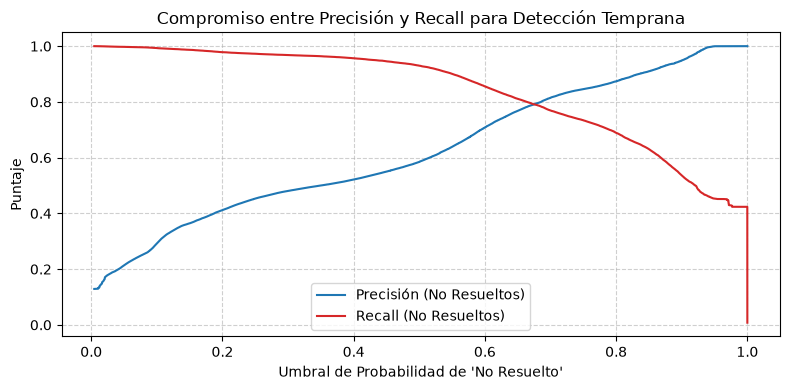

In [6]:
from sklearn.metrics import precision_recall_curve, classification_report
import matplotlib.pyplot as plt

# 1. Probabilidades para la clase minoritaria (No Resuelto = 0)
# y_proba_rf[:, 0] corresponde a la probabilidad predicha de que sea 0
proba_no_resuelto = y_proba_rf_0 = 1 - y_proba_rf

# 2. Simular predicciones con un umbral más estricto para detectar casos no resueltos
# Por defecto el corte es proba >= 0.50. Evaluamos qué pasa en 0.40:
umbral_operativo = 0.40
y_pred_ajustado = (y_proba_rf >= umbral_operativo).astype(int)

print(f"--- REPORTE CON UMBRAL AJUSTADO A {umbral_operativo} ---")
print(classification_report(y_test, y_pred_ajustado, target_names=['No Resuelto (0)', 'Cerrado (1)']))

# 3. Curva Precision-Recall para la clase 0
precision, recall, umbrales = precision_recall_curve((y_test == 0).astype(int), proba_no_resuelto)

plt.figure(figsize=(8, 4))
plt.plot(umbrales, precision[:-1], label="Precisión (No Resueltos)", color="#1f77b4")
plt.plot(umbrales, recall[:-1], label="Recall (No Resueltos)", color="#d62728")
plt.xlabel("Umbral de Probabilidad de 'No Resuelto'")
plt.ylabel("Puntaje")
plt.title("Compromiso entre Precisión y Recall para Detección Temprana")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()